### Subagents are specialized AI Agents, that the main Agent delegates tasks to.
#### Each Subagent has own context, memory, tools and instructions to perform focused job and return results

!["subagents](./notes/subagents.jpeg)


### Why use subagents?
#### Break complex tasks into manageable parts
#### Run tasks in parallel for speed
#### Isolate context to reduce noise and token usage
#### Use the right tools and skills for each job
#### Improve reliability and maintainability

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")



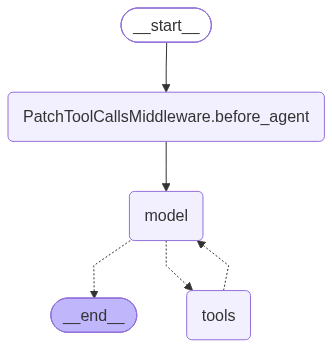

In [2]:
import os
from typing import Literal
from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ.get("TAVILY_API_KEY"))

def internet_search(query:str, 
                    max_results: int = 5, 
                    topic : Literal["general", "news", "finance"] = "general",
                    include_raw_content: bool = False,
                    ):

    """
    Perform an internet search using the Tavily API.

    Args:
        query (str): The search query.
        max_results (int): The maximum number of results to return. Default is 5.
        topic (Literal["general", "news", "finance"]): The topic of the search. Default is "general".

    Returns:
        list: A list of search results.
    """
    response = tavily_client.search(query=query, 
                                    max_results=max_results, 
                                    include_raw_content=include_raw_content, 
                                    topic=topic)
    return response.get("results", [])


research_subagent={
    "name": "research_subagent",
    "description": "A subagent that performs internet searches using the Tavily API.",
    "system_prompt": "You are a research subagent that performs internet searches using the Tavily API. You can search for information on various topics and return relevant results.",
    "tools": [internet_search],
    "models": ["groq:openai/gpt-oss-20b"],
}

subagents = [research_subagent]

agent = create_deep_agent(model="groq:openai/gpt-oss-20b",
                          subagents=subagents,
                          )

agent

In [3]:
result = agent.invoke({
    "messages": [{"role": "user", 
                  "content": "Research about LLM Gateways and provide me a detailed summary",}]},
                      config={"configurable": {"thread_id": "sub-agent"}})

for message in result["messages"]:
   message.pretty_print()

================================ Human Message =================================

Research about LLM Gateways and provide me a detailed summary
================================== Ai Message ==================================
Tool Calls:
  task (fc_5f57f71c-ae59-4936-9e68-a90f22037eef)
 Call ID: fc_5f57f71c-ae59-4936-9e68-a90f22037eef
  Args:
    description: Research LLM Gateways and provide a detailed summary.
    subagent_type: research_subagent
================================= Tool Message =================================
Name: task

**LLM Gateways – A Comprehensive Overview (2026)**  
*(All information is based on publicly available sources up to 18 Aug 2026, sourced via Tavily internet search results 2026‑08‑18)*

---

## 1. What is an LLM Gateway?

An **LLM gateway** is a middleware layer that sits between your application and one or more large‑language‑model (LLM) providers (OpenAI, Anthropic, Cohere, Mistral, etc.) or self‑hosted models.  
It exposes a **single, unified API**

In [31]:
### structered Outpout witth Sub Agents

from pydantic import BaseModel, Field
from deepagents import create_deep_agent
from langchain_core.messages import ToolMessage
from langchain.agents.structured_output import ToolStrategy

class ResearchFinding(BaseModel):
    summary: str = Field(..., description="The title of the research finding.")
    confidence: float = Field(..., description="A detailed summary of the research finding.")
    sources: list[str] = Field(..., description="The sources of the research finding.")
    
    
research_subagent = {
    "name": "researcher",
    "description": "A subagent that performs internet searches and returns structured research findings.",
    "system_prompt": "You are a research subagent that performs internet searches and returns structured research findings. You can search for information on various topics and return relevant results in a structured format.",
    "tools": [internet_search],
    "response_format": ToolStrategy(ResearchFinding),
    "model": "groq:openai/gpt-oss-120b",   # <-- neu: eigenes Modell, getrennt vom Hauptagenten
}

research_deep_agent = create_deep_agent(model="groq:groq/compound",
                          subagents=[research_subagent],
                          )

In [ ]:
## looking for grok models
from groq import Groq
client = Groq()  # liest GROQ_API_KEY aus der Umgebung
for m in client.models.list().data:
    print(m.id)


canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-22m
whisper-large-v3-turbo
openai/gpt-oss-safeguard-20b
groq/compound-mini
canopylabs/orpheus-v1-english
allam-2-7b
whisper-large-v3
meta-llama/llama-prompt-guard-2-86m
openai/gpt-oss-120b
qwen/qwen3.6-27b
groq/compound
openai/gpt-oss-20b


In [35]:
from openai import OpenAI

client = OpenAI()

candidates = [
    "gpt-4o-mini",
    "gpt-4.1-mini",
    "gpt-5-mini",
    "gpt-5.6-luna",
    "gpt-5.6-terra",
]

for model in candidates:
    try:
        response = client.chat.completions.with_raw_response.create(
            model=model,
            messages=[{"role": "user", "content": "hi"}],
            max_tokens=1,
        )
        tpm = response.headers.get("x-ratelimit-limit-tokens")
        print(f"{model:20s} TPM: {tpm}")
    except Exception as e:
        print(f"{model:20s} Fehler: {e}")

gpt-4o-mini          Fehler: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}
gpt-4.1-mini         Fehler: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}
gpt-5-mini           Fehler: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}
gpt-5.6-luna         Fehler: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at 

In [38]:
import anthropic

client = anthropic.Anthropic()

candidates = [
    "claude-haiku-4-5-20251001",
    "claude-sonnet-5",
    "claude-sonnet-4-5-20250929",
]

for model in candidates:
    try:
        response = client.messages.with_raw_response.create(
            model=model,
            max_tokens=1,
            messages=[{"role": "user", "content": "hi"}],
        )
        tpm = response.headers.get("anthropic-ratelimit-tokens-limit")
        print(f"{model:30s} TPM: {tpm}")
    except Exception as e:
        print(f"{model:30s} Fehler: {e}")

claude-haiku-4-5-20251001      Fehler: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CeAXhbKnRtxTYfMaPAR26'}
claude-sonnet-5                Fehler: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CeAXhchdqhGE64TF2xqC3'}
claude-sonnet-4-5-20250929     Fehler: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CeAXhdwo3JzKTThaYXU6e'}


In [32]:
result = await research_deep_agent.ainvoke({"messages": [{"role": "user", "content": "How is the weather today in Berlin?"}]},)

"""for message in result["messages"]:
    print(type(message).__name__, "-", getattr(message, "name", None))"""
    
for message in result["messages"]:
    print(type(message).__name__, "-", getattr(message, "name", None))
    if isinstance(message, ToolMessage) and message.name == "task":
        finding = ResearchFinding.model_validate_json(message.content)
        print("Summary:   ", finding.summary)
        print("Confidence:", finding.confidence)
        print("Sources:")
        for source in finding.sources:
            print("  -", source)

BadRequestError: Error code: 400 - {'error': {'message': '`tool calling` is not supported with this model', 'type': 'invalid_request_error', 'param': 'tool calling'}}